In [20]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [21]:
df = pd.read_csv(r'../data/raw/DHHNGSP.csv', parse_dates=['observation_date'], index_col='observation_date')
df.sort_index(inplace=True)
df

,DHHNGSP
observation_date,
2021-07-13,3.78
2021-07-14,3.80
2021-07-15,3.68
2021-07-16,3.70
2021-07-19,3.75
...,...
2026-07-07,3.13
2026-07-08,3.13
2026-07-09,3.17


In [22]:
# descriptive statistics
df.describe()

,DHHNGSP
count,1248.000000
mean,3.771699
std,2.113975
min,1.210000
25%,2.510000
50%,3.120000
75%,4.430000
max,30.720000


In [23]:
df.shape

(1305, 1)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1305 entries, 2021-07-13 to 2026-07-13
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DHHNGSP  1248 non-null   float64
dtypes: float64(1)
memory usage: 20.4 KB


In [25]:
# check null values
print(df.isnull().sum())

DHHNGSP    57
dtype: int64


In [26]:
# set target variable
y = df.columns[0]
y

'DHHNGSP'

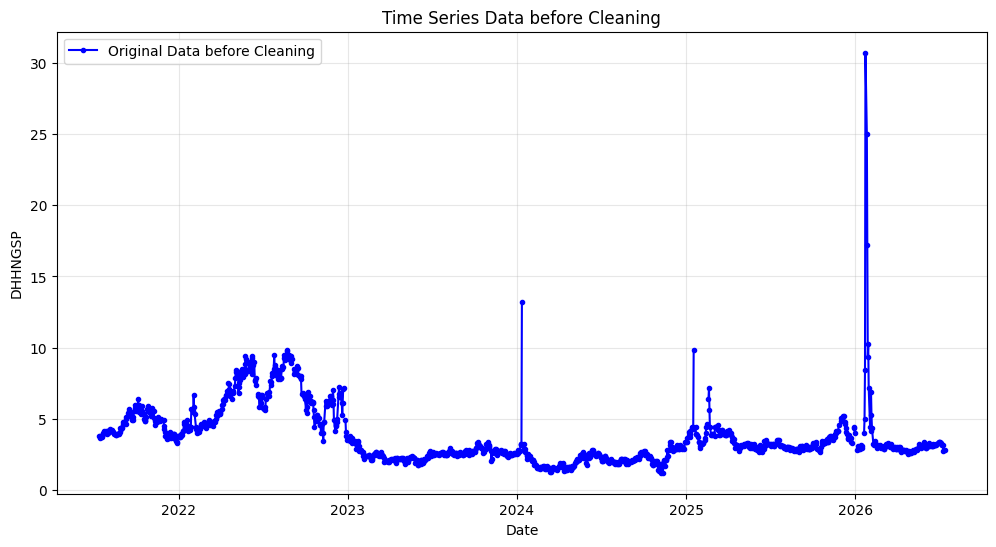

Number of missing values before cleaning: 57


In [27]:
# Visualize Before Cleaning (EDA)
plt.figure(figsize=(12, 6))
plt.plot(df.index, df[y], label='Original Data before Cleaning', color='blue', marker='.', linestyle='-')
plt.title('Time Series Data before Cleaning')
plt.xlabel('Date')
plt.ylabel('DHHNGSP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Number of missing values before cleaning:", df.isnull().sum().values[0])
         

In [28]:
# Cleaning the data by interpolating missing values using time-based interpolation
df[y] = df[y].interpolate(method='time')
print("Number of missing values after cleaning:", df.isnull().sum().values[0])

Number of missing values after cleaning: 0


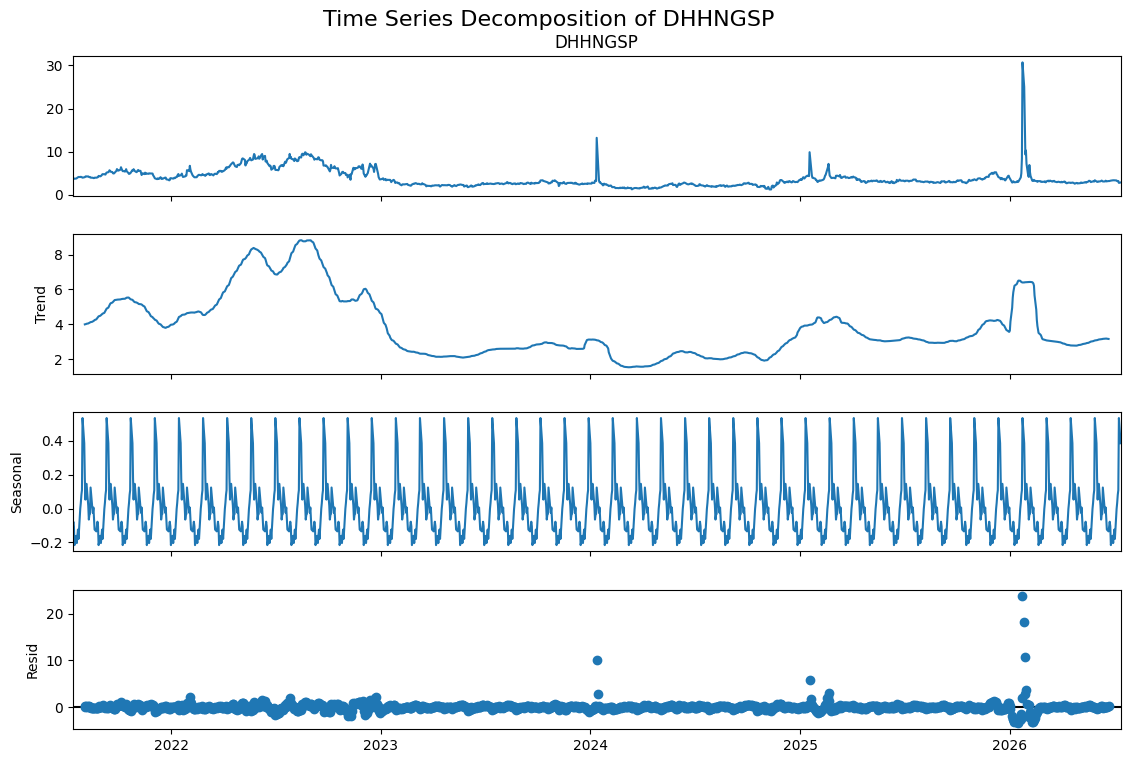

In [29]:
# Time Series Decomposition
decomposition = seasonal_decompose(df[y].dropna(), model='additive', period=30) # Assuming monthly seasonality for daily data

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle(f'Time Series Decomposition of {y}', fontsize=16)
plt.show()

In [30]:
# Feature Engineering: Create lag features
df['lag_1'] = df[y].shift(1)
df['lag_2'] = df[y].shift(7)  # Weekly lag
df['lag_3'] = df[y].shift(30)  # Monthly lag

df["Rolling_Std_7"] = df[y].rolling(window=7).std()  # 7-day rolling std

In [31]:
# Stationarity Test using ADF and Transformation
def test_stationarity(timeseries):
    """
    Run ADF test if the p-value is less than 0.05, we can reject the null hypothesis and conclude that the time series is stationary.
    """
    
    cleaned_timeseries = timeseries.dropna()  # Drop NaN values for ADF test
    print('Results of Dickey-Fuller Test:')
    results = adfuller(cleaned_timeseries)
    p_value = results[1]
    print(f'ADF Statistic: {results[0]:.4f}')
    print(f'p-value: {p_value:.4f}')
    
    if p_value > 0.05:
        print("The time series is stationary. Applying log transformation and differencing to make it stationary.")
        
        transformed_series = np.log(timeseries).diff()
        return transformed_series
    else:
        print("The time series is already stationary.No transformation needed.")
        return timeseries
    
# stationary function
df['Stationary_Target'] = test_stationarity(df[y])

#  Final data set structrure
print('Final data set structure:')
print(df.head())

Results of Dickey-Fuller Test:
ADF Statistic: -3.5191
p-value: 0.0075
The time series is already stationary.No transformation needed.
Final data set structure:
                  DHHNGSP  lag_1  lag_2  lag_3  Rolling_Std_7  \
observation_date                                                
2021-07-13           3.78    NaN    NaN    NaN            NaN   
2021-07-14           3.80   3.78    NaN    NaN            NaN   
2021-07-15           3.68   3.80    NaN    NaN            NaN   
2021-07-16           3.70   3.68    NaN    NaN            NaN   
2021-07-19           3.75   3.70    NaN    NaN            NaN   

                  Stationary_Target  
observation_date                     
2021-07-13                     3.78  
2021-07-14                     3.80  
2021-07-15                     3.68  
2021-07-16                     3.70  
2021-07-19                     3.75  


In [32]:
# Save the cleaned and feature-engineered dataset to a new CSV file. in data/processed directory
df.to_csv('../data/processed/cleaned_featured_data.csv', index=True)